# **🏠 House Price Prediction Using Linear Regression**

**Author:** Shoaib Muhammad  
**Internship:** Neurofive Solutions — Machine Learning Track  
**Task:** Regression — Predicting House Prices  
**Dataset:** California Housing Dataset

---

## 🎯 **Objective**

The objective of this task is to build a Linear Regression model that predicts house prices using selected housing-related features. In this project, the dataset is prepared, relevant features are selected, the data is divided into training and testing sets, and a Linear Regression model is trained using Scikit-learn. The model is evaluated using RMSE and R² score, and a predicted-versus-actual scatter plot is created to visually assess its performance.

# **Import Libraries**

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# **Load the Dataset**

In [2]:
# Load the California Housing dataset

housing = fetch_california_housing(as_frame=True)

# Convert the dataset into a pandas DataFrame

df = housing.frame

# Display the first five rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# **Understand the Dataset**

## **🔍 Initial Dataset Inspection**
Before building the regression model, I first inspect the dataset to understand its structure, features, target variable, and data types. This helps ensure that the data is suitable for regression analysis.

# **Dataset Information**

In [3]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# **Dataset Shape**

In [4]:
# Display the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


# **Statistical Summary**

In [5]:
# Display statistical summary

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# **Check Missing Values**

## 🧹 **Checking for Missing Values**

Before training the model, I check whether the dataset contains missing values. Missing values can cause problems during model training, so it is important to identify them before proceeding.

In [6]:
# Check for missing values

missing_values = df.isnull().sum()

print(missing_values)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


# **Select Features and Target**  

## 🎯 Feature Selection

For this regression task, I selected five features that may have a relationship with house prices:

- `MedInc` — Median income
- `HouseAge` — Median house age
- `AveRooms` — Average number of rooms
- `AveBedrms` — Average number of bedrooms
- `Population` — Population

The target variable is `MedHouseVal`, which represents the median house value.

In [7]:
# Select five features

features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population"
]

X = df[features]

# Select the target variable

y = df["MedHouseVal"]

print("Selected features:")
print(features)

print("\nTarget variable:")
print("MedHouseVal")

Selected features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']

Target variable:
MedHouseVal


# **Display Selected Data**

In [8]:
# Display the selected features and target

display(df[features + ["MedHouseVal"]].head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,3.422


 # **Train-Test Split**

## ✂️ Train-Test Split

The dataset is divided into training and testing sets. The training data is used to teach the Linear Regression model, while the test data is kept separate to evaluate how well the model performs on unseen data.

I use 80% of the data for training and 20% for testing.

In [9]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


# **Create Linear Regression Model**

## 🤖 Linear Regression Model

Linear Regression is a supervised learning algorithm used to predict a continuous numerical value. In this project, the model learns the relationship between the selected housing features and the median house value.

In [10]:
# Create the Linear Regression model

model = LinearRegression()

print("Linear Regression model created successfully.")

Linear Regression model created successfully.


# **Train the Model**

In [11]:
# Train the Linear Regression model

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# **Make Predictions**

## 🔮 Making Predictions

After training the model, I use the test dataset to generate predicted house values. These predictions are then compared with the actual house values to evaluate the model's performance.

In [12]:
# Generate predictions for the test dataset

y_pred = model.predict(X_test)

# Display the first 10 predictions

print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[1.00734957 1.55812528 2.66399044 2.64904    1.98051102 2.17526217
 2.6585644  2.16805761 2.42847892 4.22500475]


# **Compare Actual and Predicted Values**

In [13]:
# Create a DataFrame to compare actual and predicted values

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,1.007350
1,0.45800,1.558125
2,5.00001,2.663990
3,2.18600,2.649040
4,2.78000,1.980511
5,1.58700,2.175262
6,1.98200,2.658564
7,1.57500,2.168058
8,3.40000,2.428479
9,4.46600,4.225005


# **Calculate RMSE**

## 📏 Root Mean Squared Error (RMSE)

RMSE measures how far the model's predictions are from the actual values. A lower RMSE generally indicates that the predictions are closer to the actual values.

In [14]:
# Calculate Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse:.4f}")

RMSE: 0.8021


# **Calculate R² Score**

## 📊 R² Score

R², or the coefficient of determination, indicates how much of the variation in house prices is explained by the features used by the model.

A value closer to 1 generally indicates that the model explains a larger proportion of the variation in the target variable.

In [15]:
# Calculate R² score

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.5090


# **Display Final Results**

In [16]:
# Display the final model evaluation results

print("Model Evaluation Results")
print("------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------
RMSE: 0.8021
R² Score: 0.5090


# **Predicted vs Actual Scatter Plot**

## 📈 Predicted vs Actual Prices

A scatter plot is used to compare the actual house prices with the prices predicted by the Linear Regression model.

If predictions are close to the actual values, the points should generally be close to a diagonal reference line.

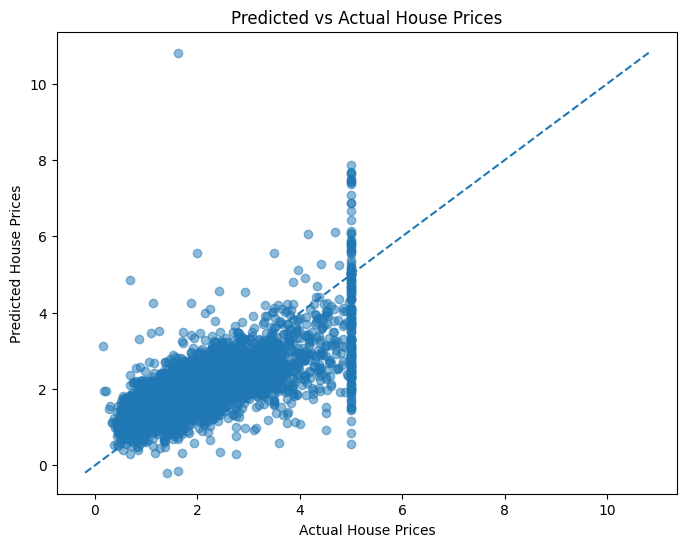

In [17]:
# Create a Predicted vs Actual scatter plot

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Add a reference line

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Predicted vs Actual House Prices")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.show()

# **Interpret the Scatter Plot**

## 🔎 Scatter Plot Interpretation

The scatter plot compares the model's predicted house values with their actual values. Points closer to the diagonal reference line indicate predictions that are closer to the actual values. Points farther from the line represent larger prediction errors. The plot provides a visual way to understand how well the Linear Regression model fits the test data.

# **R² Explanation for a Non-Technical Person**

## 💡 Understanding the R² Score

The R² score tells us how well our model explains differences in house prices. A higher R² means the model is able to explain more of the variation in prices using the selected features. For example, an R² of 0.60 would mean that the model explains about 60% of the variation in the house prices in this dataset. The remaining variation is related to other factors that are not included in our model.

# **Feature Coefficients**

In [18]:
# Display the model coefficients

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.544939
1,HouseAge,0.016604
2,AveRooms,-0.223015
3,AveBedrms,1.110462
4,Population,0.000019


# **Feature Coefficient Interpretation**

## 📌 Feature Coefficients

The coefficients show how the Linear Regression model relates each selected feature to the predicted house value while considering the other features in the model. A positive coefficient indicates a positive relationship with the predicted target, while a negative coefficient indicates a negative relationship. The size of a coefficient should be interpreted carefully because the features are measured on different scales.

# **Final Results**

## 🏆 Final Model Results

The Linear Regression model was trained using five selected housing features: median income, house age, average rooms, average bedrooms, and population.

The model was evaluated using RMSE and R² score on the test dataset. The Predicted vs Actual scatter plot was also used to visually examine the quality of the predictions.

In [19]:
# Display final results clearly

results = pd.DataFrame({
    "Metric": ["RMSE", "R² Score"],
    "Value": [rmse, r2]
})

results

,Metric,Value
0,RMSE,0.802133
1,R² Score,0.508995


# **Conclusion**



In this task, I built a Linear Regression model to predict house prices using the California Housing dataset. Five housing-related features were selected and the dataset was divided into training and testing sets. The model was evaluated using RMSE and R² score, and a Predicted vs Actual scatter plot was created to visually assess its performance. This task helped me understand the basic workflow of regression and how model evaluation metrics can be used to measure prediction quality.